In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv(r"D:\Data_anlytics_project\Gurgaon Real Estate Market Analysis\data of gurugram real Estate.csv")
df.head()

,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Socity,Company Name,Flat Type
0,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000.0,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3.0,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000.0,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4.0,Outside Socity,Outside,Plot
4,24000000.0,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3.0,Anant Raj Estate Plots,Anant,Floor


In [4]:
df.shape

(19515, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19515 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price          19515 non-null  object 
 1   Status         19515 non-null  object 
 2   Area           19515 non-null  int64  
 3   Rate per sqft  19515 non-null  object 
 4   Property Type  19515 non-null  object 
 5   Locality       19515 non-null  object 
 6   Builder Name   19515 non-null  object 
 7   RERA Approval  19515 non-null  object 
 8   BHK_Count      19515 non-null  float64
 9   Socity         19515 non-null  object 
 10  Company Name   19515 non-null  object 
 11  Flat Type      19515 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 1.8+ MB


In [6]:
df.head(2)

,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Socity,Company Name,Flat Type
0,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000.0,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3.0,M3M Antalya Hills Phase I,M3M,Apartment


In [7]:
df.columns

Index(['Price', 'Status', 'Area', 'Rate per sqft', 'Property Type', 'Locality',
       'Builder Name', 'RERA Approval', 'BHK_Count', 'Socity', 'Company Name',
       'Flat Type'],
      dtype='object')

In [10]:
df.columns

Index(['price', 'status', 'area', 'rate-per-sqft', 'property-type', 'locality',
       'builder-name', 'rera-approval', 'bhk_count', 'socity', 'company-name',
       'flat-type'],
      dtype='object')

In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","-")

In [11]:
df.dtypes

price             object
status            object
area               int64
rate-per-sqft     object
property-type     object
locality          object
builder-name      object
rera-approval     object
bhk_count        float64
socity            object
company-name      object
flat-type         object
dtype: object

#  Convert Numeric Columns

In [14]:
df.isna().sum()

price            0
status           0
area             0
rate-per-sqft    0
property-type    0
locality         0
builder-name     0
rera-approval    0
bhk_count        0
socity           0
company-name     0
flat-type        0
dtype: int64

In [16]:
df["price"] = df["price"].astype(str).str.replace(",", "").astype(float).astype(int)
df["area"] = df["area"].astype(str).str.replace(",", "").astype(int)
df["rate-per-sqft"] = df["rate-per-sqft"].astype(str).str.replace(",", "").astype(int)

#  Clean Categorical Columns

In [ ]:
df["status"] = df["status"].str.strip().str.lower()

df["rera_approval"] = df["rera_approval"].str.strip().str.lower()

df["flat_type"] = df["flat_type"].str.strip().str.lower()

###### Avoids duplicate categories caused by inconsistent formatting

In [ ]:
df = df.drop_duplicates()

Duplicate rows can skew averages and insights

### Business Questions with Analysis

### Which is the costliest flat?

In [18]:
df.loc[df["price"].idxmax()]

price                                  1226300000
status                              Ready to move
area                                        16500
rate-per-sqft                               74323
property-type    6 BHK Apartment in DLF Camellias
locality                                Sector 42
builder-name                    Provident Capital
rera-approval                Not approved by RERA
bhk_count                                     6.0
socity                              DLF Camellias
company-name                                  DLF
flat-type                               Apartment
Name: 2839, dtype: object

Identifies the highest priced property directly

### Which locality has the highest average price?

In [22]:
df.groupby("locality")["price"].mean().sort_values(ascending=False)

locality
Baliawas                5.833333e+08
Sector 42               5.023612e+08
Beverly Park            1.953667e+08
Aralias Drive           1.636583e+08
Golf Course Road        1.475139e+08
                            ...     
Sohna Rewari Road       6.200000e+05
SULTANPUR BIRD CENTU    6.000000e+05
Sultanpur               4.875000e+05
Sector 1 Sohna          2.600000e+05
Sector-59 Gurgaon       1.700000e+05
Name: price, Length: 245, dtype: float64

Grouping helps compare average prices across localities

### Which locality has the highest rate per square foot?

In [24]:
df.groupby("locality")["rate-per-sqft"].mean().sort_values(ascending=False)

locality
Sector 42                 55989.083333
Sector 113                52404.145374
Sector 114                33347.200000
Sector 53                 29202.789474
Sector 54                 28109.250871
                              ...     
Sohna Palwal Road           688.000000
Sohna Rewari Road           688.000000
Sector 1 Sohna              577.000000
Sector-59 Gurgaon           188.000000
37D Dwarka Exp Gurgaon      125.000000
Name: rate-per-sqft, Length: 245, dtype: float64

Rate per sqft highlights premium locations independent of property size


### Ready-to-move vs Under-construction pricing

In [25]:
df.groupby("status")["price"].median()

status
New                   13450000.0
Ready to move         26000000.0
Resale                36500000.0
Under Construction    28600000.0
Name: price, dtype: float64

Median is preferred over mean due to outliers in property prices


### Does RERA approval affect pricing?

In [27]:
df.groupby("rera-approval")["price"].median()

rera-approval
Approved by RERA        27100000.0
Not approved by RERA    25800000.0
Name: price, dtype: float64

Helps measure trust premium associated with regulatory approval

###  How does area impact price?

NameError: name 'plt' is not defined

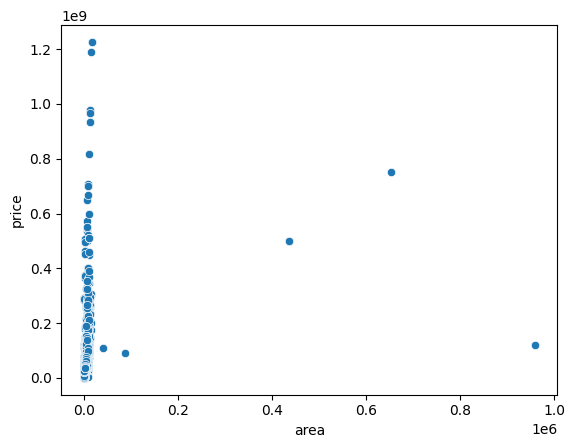

In [30]:
sns.scatterplot(x="area", y="price", data=df)
plt.show()

Visual inspection reveals correlation and pricing behavior

### Which BHK configuration is most expensive?

In [31]:
df.groupby("bhk_count")["price"].mean()

bhk_count
0.0      2.971900e+07
1.0      1.291090e+07
2.0      1.565556e+07
3.0      3.076041e+07
4.0      5.818936e+07
5.0      1.217361e+08
6.0      1.691315e+08
7.0      2.193125e+08
8.0      6.801000e+07
9.0      3.575000e+07
10.0     9.500000e+07
12.0     5.333333e+07
15.0     8.540000e+07
16.0     1.700000e+06
34.0     7.500000e+06
39.0     5.250000e+07
45.0     4.100000e+07
47.0     8.900000e+06
89.0     8.550000e+06
95.0     1.164000e+07
99.0     2.478000e+07
102.0    5.000000e+07
112.0    2.416667e+07
114.0    4.350000e+07
132.0    5.700000e+07
Name: price, dtype: float64

Helps identify demand and pricing by family size

###  Which property type is the costliest?

In [33]:
df.groupby("flat-type")["price"].mean()

flat-type
Apartment    4.172806e+07
Floor        3.028492e+07
House        1.247044e+08
Penthouse    1.378469e+08
Plot         2.670731e+07
Villa        9.329317e+07
Name: price, dtype: float64

Compares Apartments, Floors, and Plots fairly


### Do certain builders price higher?

In [35]:
df.groupby("company-name")["price"].mean().sort_values(ascending=False)

company-name
Baliawas       7.500000e+08
Camelliaass    4.433333e+08
Cameliaas      3.600000e+08
Magnoliaass    1.600000e+08
Magnoliaaa     1.600000e+08
                   ...     
JMD            1.300000e+06
u              7.023330e+05
OM             7.019166e+05
SOHNA          6.500000e+05
SR             2.365000e+05
Name: price, Length: 269, dtype: float64

### Are larger homes more expensive per sqft?

NameError: name 'plt' is not defined

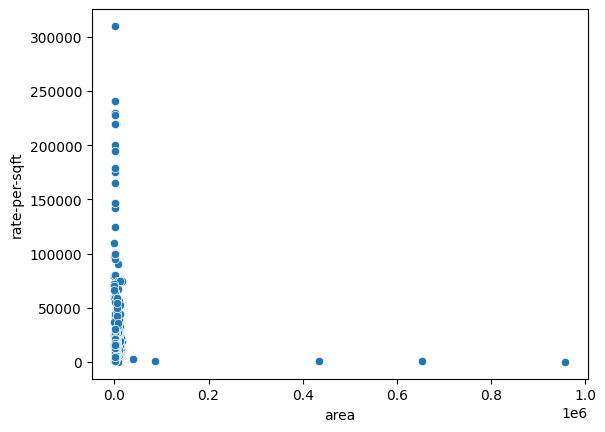

In [37]:
sns.scatterplot(x="area", y="rate-per-sqft", data=df)
plt.show()

Helps evaluate economies of scale in real estate pricing

From the analysis, we can conclude:

            Premium localities consistently show higher prices and rate per sqft
            Ready-to-move and RERA-approved properties tend to command higher prices
            Builder reputation significantly impacts property pricing
            Larger homes are not always more expensive per sqft
            Apartments generally have higher rate per sqft than plots and floors